In [1]:
# --- Core scientific stack ---
import numpy as np
from matplotlib import pyplot as plt

# --- Vectorized figures and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

In [2]:
def generate_example_signal(dur=1, sr=100):
    """Generate the example signal."""
    N = int(round(sr * dur))
    t = np.arange(N) / sr
    x =  0.8 * np.sin(2 * np.pi * (1.9 * t - 0.3))
    x += 0.5 * np.sin(2 * np.pi * (6.1 * t - 0.1))
    x += 0.3 * np.sin(2 * np.pi * (16 * t - 0.2))
    return x, t

def generate_sinusoid(dur=1, amp=1, freq=1, phase=0, sr=4000):
    """Generate a sampled sinusoid."""
    t = np.arange(int(dur * sr)) / sr
    x = amp * np.sin(2 * np.pi * (freq * t - phase))
    return x, t, sr

def plot_inner_product_real(ax, n, x, y, label_x, label_y,
                            color_x='black', color_y='red'):
    """Plot two real signals and their inner product."""
    ax.plot(n, x, color=color_x, label=rf'${label_x}$')
    if y is not x:
        ax.plot(n, y, color=color_y, label=rf'${label_y}$')

    value = np.dot(x, y)
    ax.set(
        xlim=(n[0], n[-1]), ylim=(-1.8, 1.8),
        xlabel='Sample index $n$', ylabel='Signal value',
        title=rf'$\langle {label_x},{label_y}\rangle={value:.1f}$',
    )
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', framealpha=1)

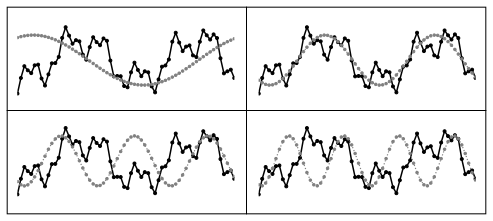

In [15]:
sr = 64
freqs = [1, 2, 3, 4]

height = 3
width = 12.5 / 5.5 * height    # required ratio

x, _ = generate_example_signal(dur=1, sr=sr)

def plot_frequency_comparison_optimal(ax, x, freq, sr):
    """Compare a signal with a complex exponential or optimal cosine."""
    N = len(x)
    n = np.arange(N)
    e = np.exp(2j * np.pi * freq * n / sr)
    c = np.vdot(e, x)

    ax.plot(n, x, 'ko-', ms=3, lw=1.5, label='$x$')

    phase = (-np.angle(c) / (2 * np.pi)) % 1
    cos_opt = np.cos(2 * np.pi * (freq * n / sr - phase))
    ax.plot(n, cos_opt, color='gray', ls=':', marker='o', ms=2.5, lw=1.2,
            label=rf'$\cos_{{{freq},\mathrm{{opt}}}}$')

    ax.set(xlim=(0, N - 1), ylim=(-1.8, 1.8), xticks=[], yticks=[])
    ax.set_axis_off()

fig, ax = plt.subplots(2, 2, figsize=(width, height), layout='constrained')
fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02, wspace=0.10, hspace=0.1,
                            rect=(0.03, 0.05, 0.94, 0.90))

for idx, freq in enumerate(freqs):
    plot_frequency_comparison_optimal(ax.flat[idx], x, freq, sr)

# --- Black frame around the grid plus two dividers between the panels ---
x0, y0, w, h = 0.012, 0.02, 0.976, 0.96
fig.add_artist(plt.Rectangle(
    (x0, y0), w, h, transform=fig.transFigure,
    fill=False, edgecolor='black', lw=1.0,
))
fig.add_artist(plt.Line2D(
    [x0 + w / 2] * 2, [y0, y0 + h], transform=fig.transFigure,
    color='black', lw=1.0,
))
fig.add_artist(plt.Line2D(
    [x0, x0 + w], [y0 + h / 2] * 2, transform=fig.transFigure,
    color='black', lw=1.0,
))

plt.savefig("teaser_figure.pdf")